In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import os

import matplotlib.pyplot as plt
plt.style.use("~/mpl_styles/cs_paper.mplstyle")

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [ ]:
import pickle
import pandas as pd
BASE = "../experiment_results/mnist_scan/"
files = os.listdir(BASE)

dfs = []
for f in files:
    dfs.append(pd.read_pickle(os.path.join(BASE, f)))

scan_results = pd.concat(dfs, ignore_index=True)

In [30]:
batch_sizes = sorted(list(set(scan_results['batch_size'].values)))
k_fracs = scan_results['k_fraction'].values
k_fracs = k_fracs[~np.isnan(k_fracs)]
k_fracs = sorted(list(set(k_fracs)))
lrs = sorted(list(set(scan_results[scan_results['optimizer']=='SVD']['lr'].values)))

k_labels = {0.1:"B/10", 0.25:"B/4", 0.5:"B/2", 0.75:"3B/4", 1.0:"B"}

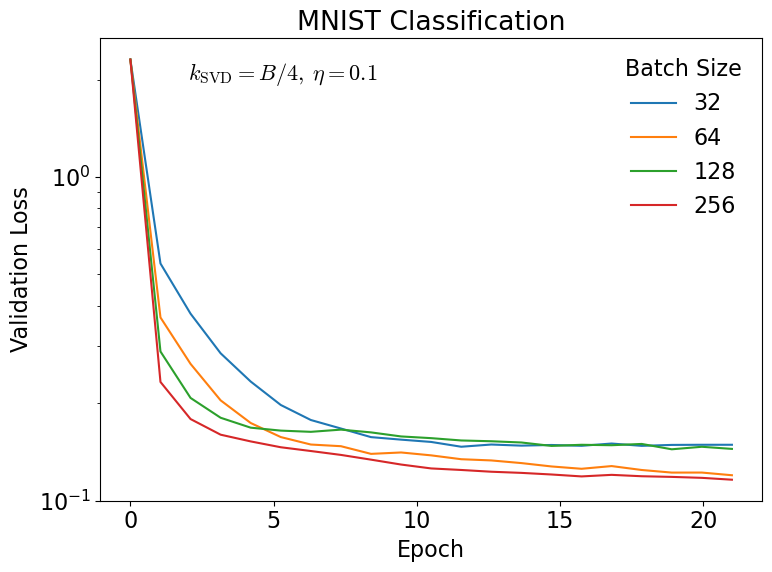

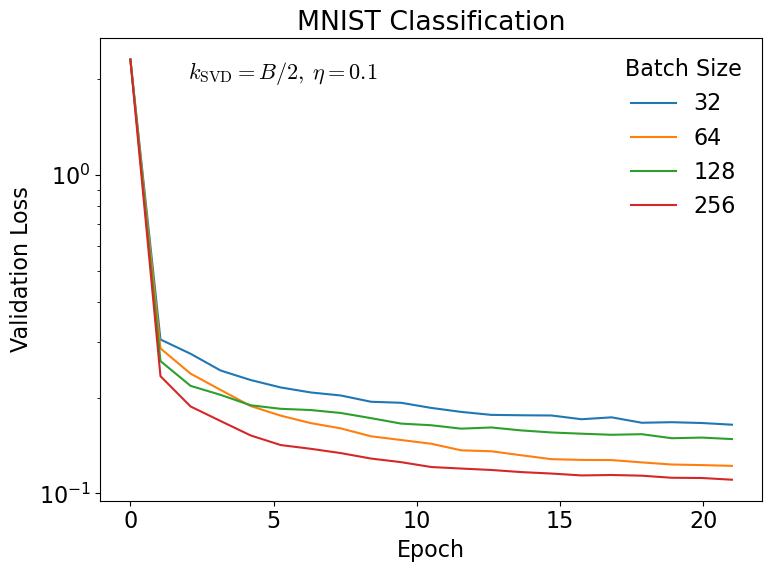

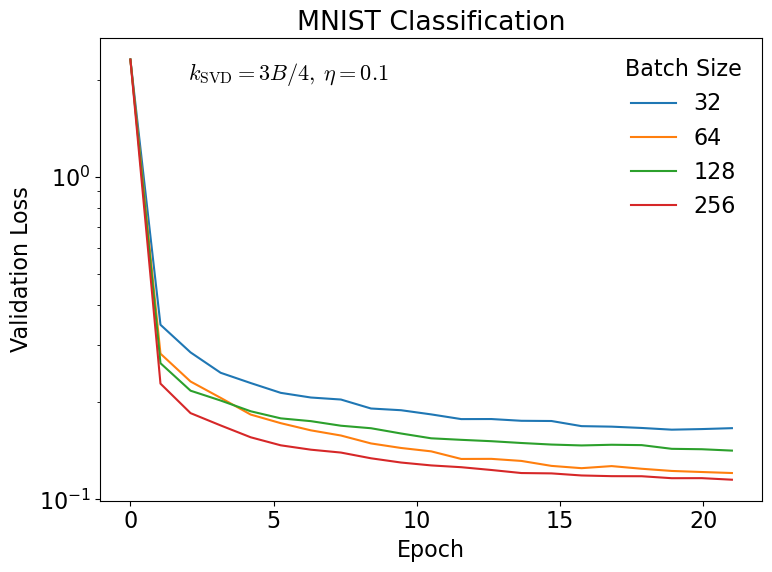

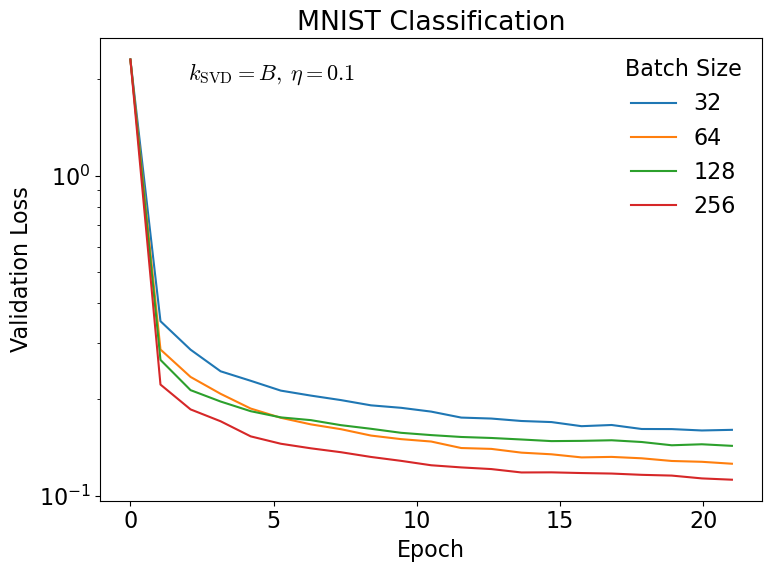

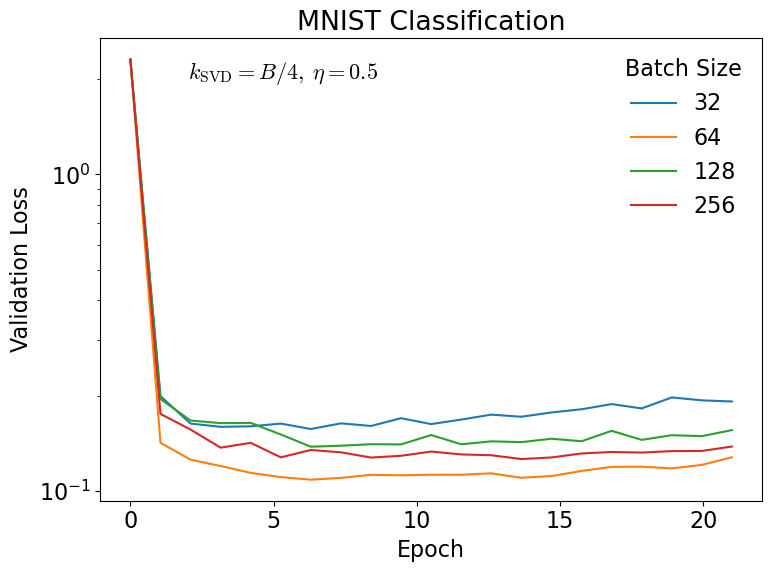

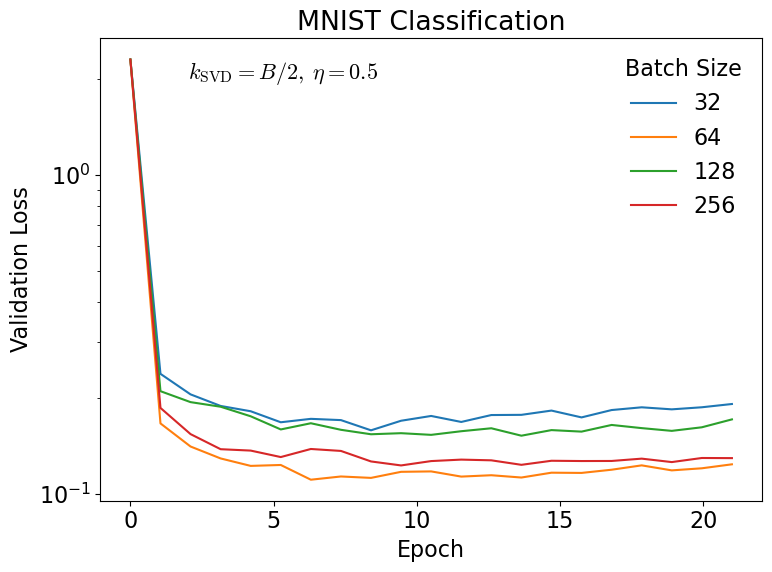

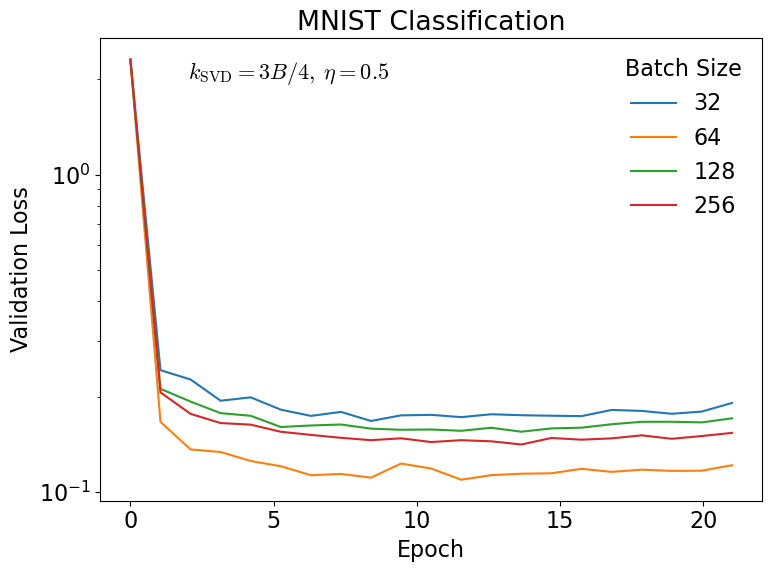

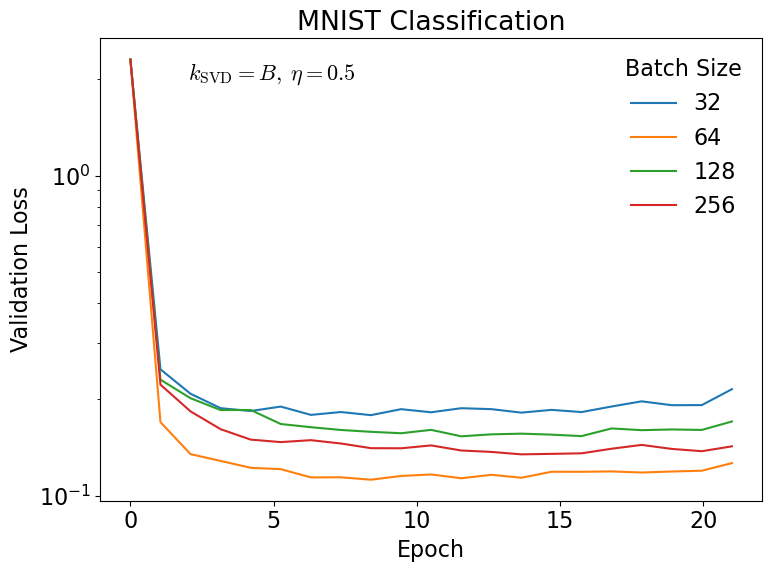

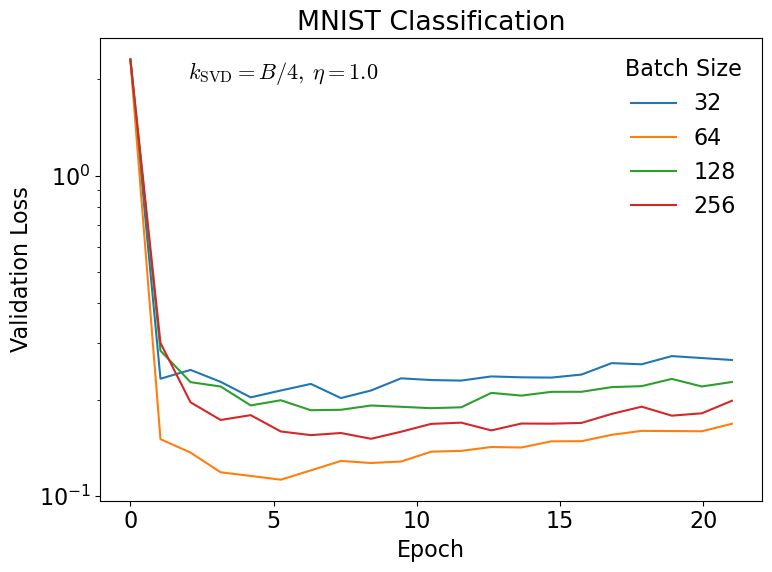

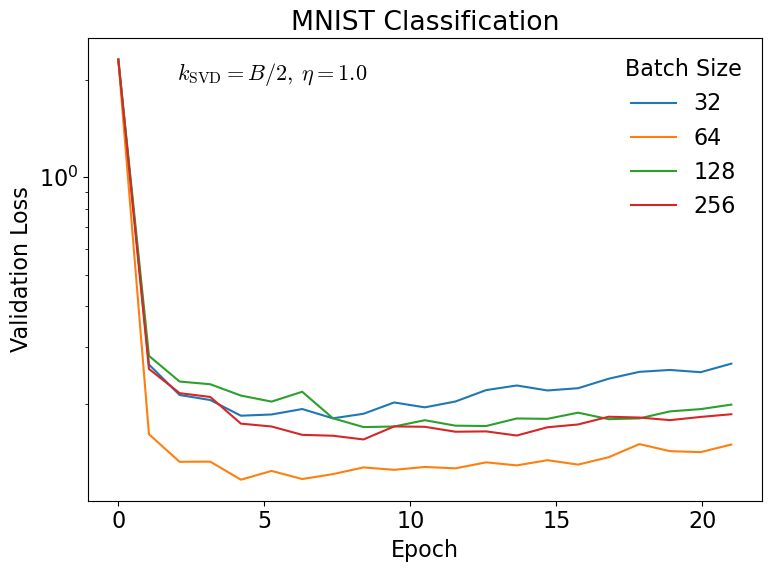

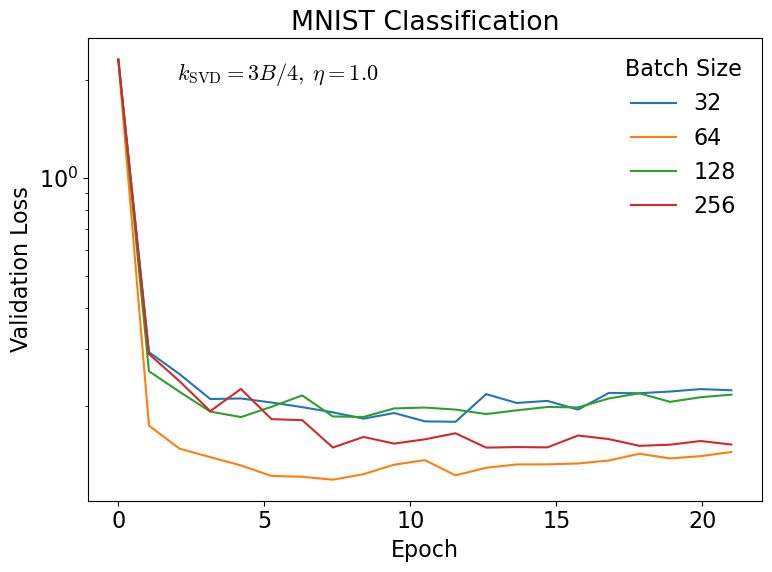

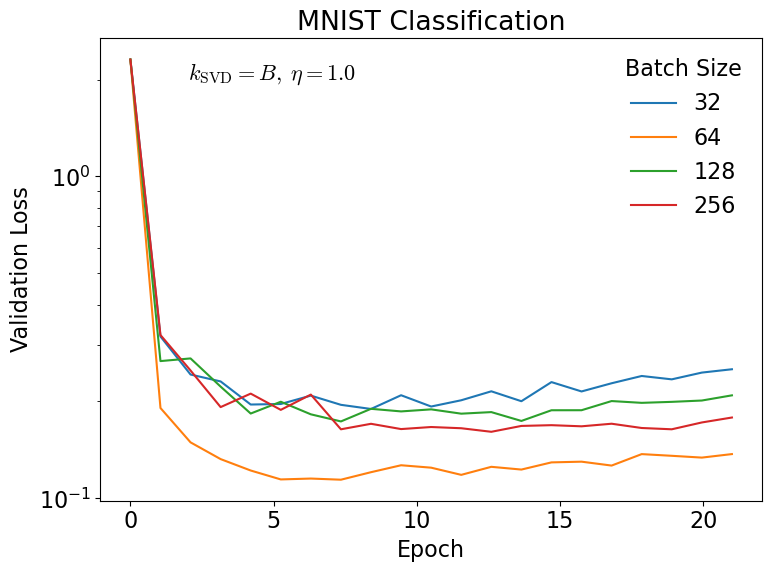

In [32]:
for LR_VAL in lrs:
    for K_FRAC in k_fracs:
        plt.figure(figsize=(8,6))
        for bs in batch_sizes:
            k = (bs,K_FRAC,LR_VAL)
            cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL)
            res = scan_results[cut].iloc[0]
            n_epoch = len(res['losses']['val'])
            xvals = np.linspace(0,n_epoch,len(res['losses']['val']))
            plt.plot(xvals, res['losses']['val'], label=f'{bs}')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.yscale('log')
        plt.legend(title='Batch Size')
        plt.title(rf"MNIST Classification")
        plt.text(2,2,rf"$k_\text{{SVD}} = {k_labels[K_FRAC]}, \; \eta = {LR_VAL}$",fontsize=16)
        plt.tight_layout()
        plt.savefig(f"mnist_plots/mnist_val_loss_bsOverlay_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
        plt.show()

# Fix batch size, compare optimizers

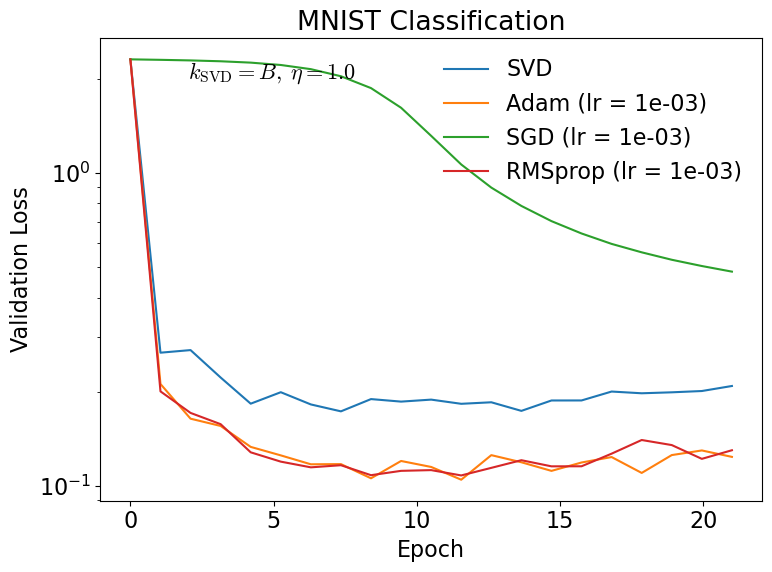

In [53]:
K_FRAC = 1.0 # full batch
LR_VAL = 1.0 # small-ish LR
MLP_WIDTH = 32
bs = 128
lr_normal = 1e-3
plt.figure(figsize=(8,6))
k = (bs,K_FRAC,LR_VAL)
cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL) & (scan_results['optimizer'] == "SVD") & (scan_results['mlp_width'] == MLP_WIDTH)
res = scan_results[cut].iloc[0]
n_epoch = len(res['losses']['val'])
xvals = np.linspace(0,n_epoch,len(res['losses']['val']))
plt.plot(xvals, res['losses']['val'], label=f'SVD')
for opt in ["Adam","SGD","RMSprop"]:
    cut = (scan_results['batch_size'] == bs) & (scan_results['lr'] == lr_normal) & (scan_results['optimizer'] == opt) & (scan_results['mlp_width'] == MLP_WIDTH)
    res = scan_results[cut].iloc[0]
    n_epoch = len(res['losses']['val'])
    xvals = np.linspace(0,n_epoch,len(res['losses']['val']))
    plt.plot(xvals, res['losses']['val'], label=f'{opt} (lr = {lr_normal:.0e})')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.yscale('log')
plt.title(rf"MNIST Classification")
plt.text(2,2,rf"$k_\text{{SVD}} = {k_labels[K_FRAC]}, \; \eta = {LR_VAL}$",fontsize=16)
plt.tight_layout()
#plt.savefig(f"mnist_plots/mnist_val_loss_individual_bs_{bs}_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
plt.show()


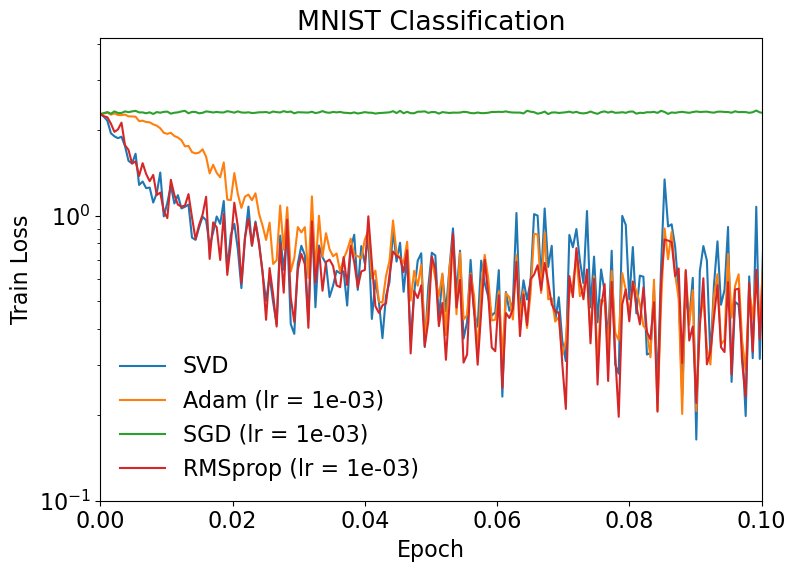

In [ ]:
K_FRAC = 1.0 # full batch
LR_VAL = 0.1 # small-ish LR
MLP_WIDTH = 32
bs = 32
lr_normal = 1e-3
plt.figure(figsize=(8,6))
k = (bs,K_FRAC,LR_VAL)
cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL) & (scan_results['optimizer'] == "SVD") & (scan_results['mlp_width'] == MLP_WIDTH)
res = scan_results[cut].iloc[0]
n_epoch = len(res['losses']['train'])
xvals = np.linspace(0,n_epoch,len(res['losses']['train_batch']))
plt.plot(xvals, res['losses']['train_batch'], label=f'SVD')
for opt in ["Adam","SGD","RMSprop"]:
    cut = (scan_results['batch_size'] == bs) & (scan_results['lr'] == lr_normal) & (scan_results['optimizer'] == opt) & (scan_results['mlp_width'] == MLP_WIDTH)
    res = scan_results[cut].iloc[0]
    n_epoch = len(res['losses']['train'])
    xvals = np.linspace(0,n_epoch,len(res['losses']['train_batch']))
    plt.plot(xvals, res['losses']['train_batch'], label=f'{opt} (lr = {lr_normal:.0e})')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.yscale('log')
plt.title(rf"MNIST Classification")
plt.tight_layout()
plt.xlim([0,0.1])
#plt.savefig(f"mnist_plots/mnist_val_loss_individual_bs_{bs}_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
plt.ylim([1e-1,None])
plt.show()


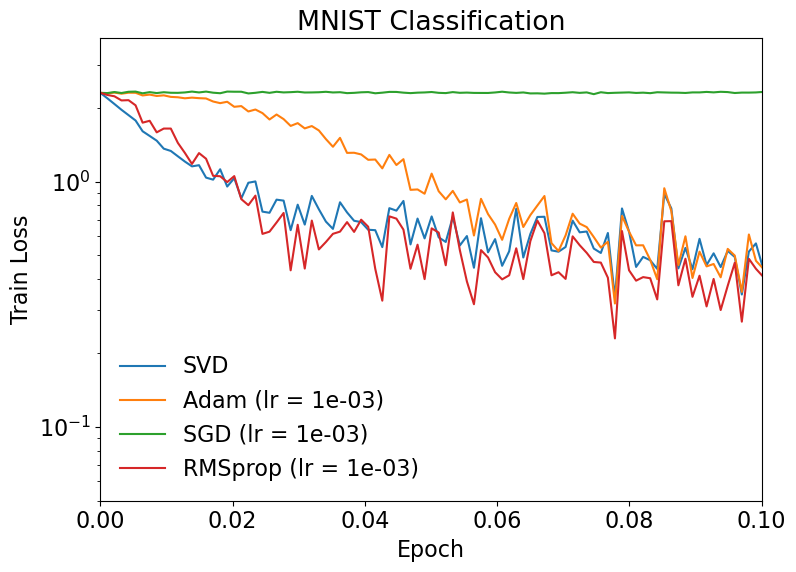

In [79]:
K_FRAC = 0.5 # full batch
LR_VAL = 0.1 # small-ish LR
smoothing_window = 1  # configurable smoothing width
MLP_WIDTH = 32
bs = 64
lr_normal = 1e-3
plt.figure(figsize=(8,6))
k = (bs,K_FRAC,LR_VAL)
cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL) & (scan_results['optimizer'] == "SVD") & (scan_results['mlp_width'] == MLP_WIDTH)
res = scan_results[cut].iloc[0]
n_epoch = len(res['losses']['train'])
yvals = res['losses']['train_batch']
yvals = np.convolve(yvals, np.ones(smoothing_window)/smoothing_window, mode='valid')
xvals = np.linspace(0,n_epoch,len(yvals))
plt.plot(xvals, yvals, label=f'SVD')
for opt in ["Adam","SGD","RMSprop"]:
    cut = (scan_results['batch_size'] == bs) & (scan_results['lr'] == lr_normal) & (scan_results['optimizer'] == opt) & (scan_results['mlp_width'] == MLP_WIDTH)
    res = scan_results[cut].iloc[0]
    n_epoch = len(res['losses']['train'])
    yvals = res['losses']['train_batch']
    yvals = np.convolve(yvals, np.ones(smoothing_window)/smoothing_window, mode='valid')
    xvals = np.linspace(0,n_epoch,len(yvals))
    plt.plot(xvals, yvals, label=f'{opt} (lr = {lr_normal:.0e})')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.yscale('log')
plt.title(rf"MNIST Classification")
plt.tight_layout()
plt.xlim([0,0.1])
#plt.savefig(f"mnist_plots/mnist_val_loss_individual_bs_{bs}_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
plt.ylim([5e-2,None])
plt.show()
